# Initial Preparation

## Library Importation

In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Importation

In [59]:
df = pd.read_csv('Final_Unscaled_Data.csv')

In [60]:
df.columns=df.columns.str.strip()

## Split Feature and target variable

In [61]:
X = df[['Energy_Usage_kWh', 'Transportation_Distance_km', 'Plastic_Usage_kg']]
y = df['Carbon_Emission_kgCO2']

## Spliting Dataset

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Algorithm Selection

## Define the model to test

In [63]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

## Linear Regression

In [64]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

## Random Forest

In [65]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

## Evaluation and Comparation

In [66]:
results = {
    "Metric": ["R-squared (R2)", "Mean Absolute Error (MAE)", "Root Mean Absolute Error (RMAE)"],
    "Linear Regression": [r2_score(y_test, y_pred_lr), mean_absolute_error(y_test, y_pred_lr), np.sqrt(mean_absolute_error(y_test, y_pred_lr))],
    "Random Forest": [r2_score(y_test, y_pred_rf), mean_absolute_error(y_test, y_pred_rf), np.sqrt(mean_absolute_error(y_test, y_pred_rf))]
}

results_df = pd.DataFrame(results)
print("--- Model Comparison Table ---")
print(results_df)

--- Model Comparison Table ---
                            Metric  Linear Regression  Random Forest
0                   R-squared (R2)           0.853666       0.830341
1        Mean Absolute Error (MAE)           2.956148       3.143701
2  Root Mean Absolute Error (RMAE)           1.719345       1.773048


## Visualization

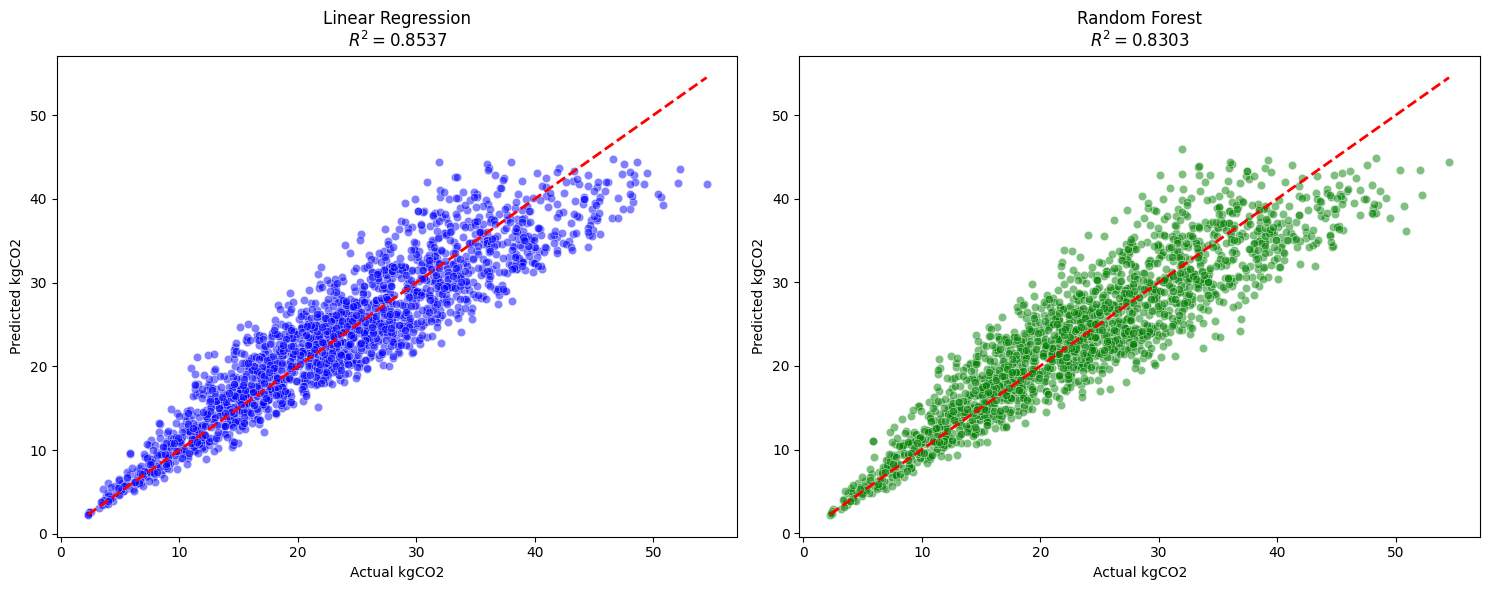

Since R^2 of Linear Regression is higher than that of Random Forest, we can conclude that Linear Regression performs better in predicting carbon emissions based on the given features.


In [67]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot Linear Regression
sns.scatterplot(x=y_test, y=y_pred_lr, ax=ax[0], color='blue', alpha=0.5)
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[0].set_title(f"Linear Regression\n$R^2 = {results['Linear Regression'][0]:.4f}$")
ax[0].set_xlabel("Actual kgCO2")
ax[0].set_ylabel("Predicted kgCO2")

# Plot Random Forest
sns.scatterplot(x=y_test, y=y_pred_rf, ax=ax[1], color='green', alpha=0.5)
ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[1].set_title(f"Random Forest\n$R^2 = {results['Random Forest'][0]:.4f}$")
ax[1].set_xlabel("Actual kgCO2")
ax[1].set_ylabel("Predicted kgCO2")

plt.tight_layout()
plt.show()

print("Since R^2 of Linear Regression is higher than that of Random Forest, we can conclude that Linear Regression performs better in predicting carbon emissions based on the given features.")

# Model Training and saving (Linear Regression)

In [68]:
features = ['Energy_Usage_kWh', 'Transportation_Distance_km', 'Plastic_Usage_kg']
coefficients = lr_model.coef_
intercept = lr_model.intercept_

print("--- Model Equation ---")
for feat, coef in zip(features, coefficients):
    print(f"{feat}: {coef:.4f}")
print(f"Base Intercept: {intercept:.4f}")

--- Model Equation ---
Energy_Usage_kWh: 0.4969
Transportation_Distance_km: 0.1997
Plastic_Usage_kg: 3.5413
Base Intercept: 0.3160


       FINAL MODEL PERFORMANCE        
R-squared (R2):          0.8537
Mean Absolute Error:     2.9561 kg
Root Mean Squared Error:  1.7193 kg
----------------------------------------
       LEARNED EQUATION WEIGHTS       
----------------------------------------
Energy_Usage_kWh         : 0.4969
Transportation_Distance_km: 0.1997
Plastic_Usage_kg         : 3.5413
Intercept (Base)         : 0.3160


/var/folders/86/4l8s2b4s5n93y597sjvnw7180000gn/T/ipykernel_3352/552258491.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Impact_Weight', y='Activity', data=importance_df, palette='magma')


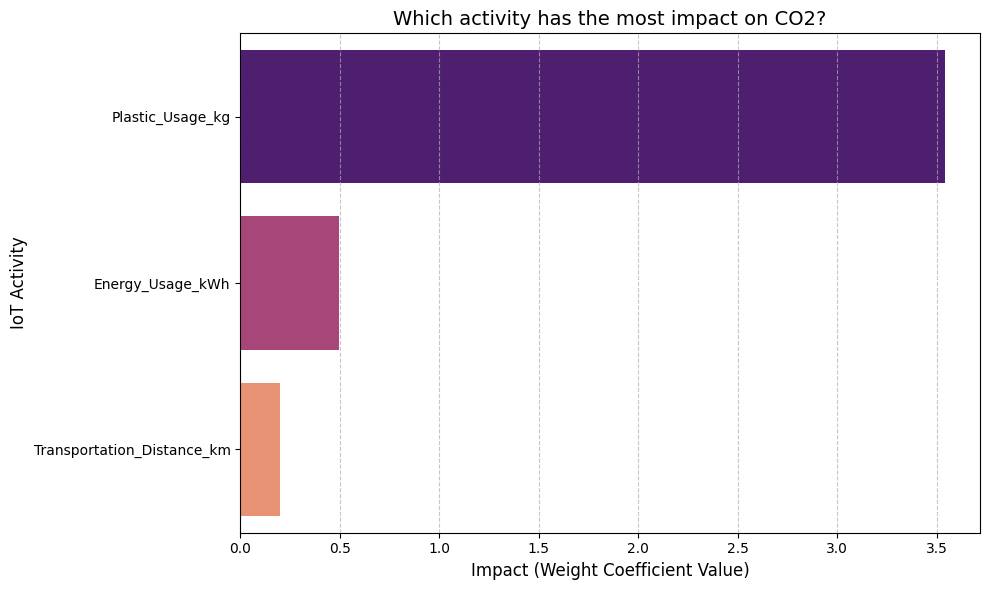

In [69]:
# PRINT THE RESULTS FOR YOUR SLIDES
print("="*40)
print("       FINAL MODEL PERFORMANCE        ")
print("="*40)
print(f"R-squared (R2):          {r2_score(y_test, y_pred_lr):.4f}")
print(f"Mean Absolute Error:     {mean_absolute_error(y_test, y_pred_lr):.4f} kg")
print(f"Root Mean Squared Error:  {np.sqrt(mean_absolute_error(y_test, y_pred_lr)):.4f} kg")
print("-" * 40)
print("       LEARNED EQUATION WEIGHTS       ")
print("-" * 40)

for feat, coef in zip(features, coefficients):
    print(f"{feat:25}: {coef:.4f}")
print(f"{'Intercept (Base)':25}: {intercept:.4f}")
print("="*40)

# 7. VISUALIZATION: Feature Importance (The "Story")
plt.figure(figsize=(10, 6))
importance_df = pd.DataFrame({'Activity': features, 'Impact_Weight': np.abs(coefficients)})
importance_df = importance_df.sort_values(by='Impact_Weight', ascending=False)

sns.barplot(x='Impact_Weight', y='Activity', data=importance_df, palette='magma')
plt.title('Which activity has the most impact on CO2?', fontsize=14)
plt.xlabel('Impact (Weight Coefficient Value)', fontsize=12)
plt.ylabel('IoT Activity', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [70]:
import joblib
# Clean column names before training
X_train.columns = X_train.columns.str.strip()
X_test.columns = X_test.columns.str.strip()

# Retrain with clean names
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Save
joblib.dump(lr_model, 'carbon_predictor_model.pkl')
# Save the model to a file
joblib.dump(lr_model, 'carbon_predictor_model.pkl')
print("Model saved as 'carbon_predictor_model.pkl'")

Model saved as 'carbon_predictor_model.pkl'
